In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
sns.set_theme(style='whitegrid', context='notebook')


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'depmap_24Q4' / 'architecture' / 'model_master.csv').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repository.')


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA = PROJECT_ROOT / 'data'
CORE = DATA / 'depmap_24Q4'

PATHS = {
    'master': CORE / 'architecture' / 'model_master.csv',
    'profile_crosswalk': CORE / 'derived' / 'profile_crosswalk.csv',
    'mutations': CORE / 'derived' / 'mutations_default_dna_gene_summary.csv',
    'fusions': CORE / 'derived' / 'fusions_filtered_model.csv',
    'signatures': CORE / 'derived' / 'signatures_model.csv',
    'conditions': CORE / 'derived' / 'model_condition_context.csv',
    'crispr_qc': CORE / 'derived' / 'crispr_screen_qc_model.csv',
    'expanded_coverage': CORE / 'derived' / 'expanded_layer_coverage.csv',
    'context_coverage': CORE / 'derived' / 'context_and_supplementary_coverage.csv',
    'proteomics': CORE / 'supplementary' / 'proteomics_model.csv',
    'mirna': CORE / 'supplementary' / 'mirna_model.csv',
    'metabolomics': CORE / 'supplementary' / 'metabolomics_model.csv',
    'prism': DATA / 'external' / 'prism_repurposing' / 'raw' / 'primary-screen-replicate-collapsed-logfold-change.csv',
}

master = pd.read_csv(PATHS['master'], low_memory=False)
profile_crosswalk = pd.read_csv(PATHS['profile_crosswalk'], low_memory=False)
expanded_coverage = pd.read_csv(PATHS['expanded_coverage'], low_memory=False)
context_coverage = pd.read_csv(PATHS['context_coverage'], low_memory=False)
prism_ids_raw = pd.read_csv(PATHS['prism'], usecols=[0]).iloc[:, 0].dropna().astype(str)

assert master['model_id'].is_unique
assert master['model_id'].notna().all()

print(f'Project root: {PROJECT_ROOT}')
print(f'Identity spine: {len(master):,} unique models')
print(f'PRISM source labels: {prism_ids_raw.nunique():,}')
display(master[['model_id', 'cell_line_name', 'oncotree_lineage']].head())

Project root: C:\Users\Avishek\Desktop\AZ_project_data\code\az-team25
Identity spine: 2,105 unique models
PRISM source labels: 578


,model_id,cell_line_name,oncotree_lineage
0,ACH-000001,NIH:OVCAR-3,Ovary/Fallopian Tube
1,ACH-000002,HL-60,Myeloid
2,ACH-000003,CACO2,Bowel
3,ACH-000004,HEL,Myeloid
4,ACH-000005,HEL 92.1.7,Myeloid


In [2]:
scope = pd.DataFrame([
    {'source_family': 'DepMap molecular and CRISPR layers', 'analysis_axis': 'Cell-line model', 'join_key': 'model_id', 'included_here': 'Yes', 'role': 'Primary cross-layer coverage'},
    {'source_family': 'Model conditions and CRISPR QC', 'analysis_axis': 'Condition/screen linked to model', 'join_key': 'model_id after retaining provenance IDs', 'included_here': 'Yes', 'role': 'Confidence and confounding context'},
    {'source_family': 'Proteomics, miRNA, metabolomics', 'analysis_axis': 'Cell-line model', 'join_key': 'model_id', 'included_here': 'Yes', 'role': 'Supplementary, release-unmatched validation'},
    {'source_family': 'PRISM drug response', 'analysis_axis': 'Cell-line model', 'join_key': 'model_id when directly matched', 'included_here': 'Yes', 'role': 'External treatment validation'},
    {'source_family': 'TCGA', 'analysis_axis': 'Patient/tumour', 'join_key': 'Project or disease context only', 'included_here': 'No', 'role': 'Later tumour-level validation'},
    {'source_family': 'Reactome, STRING, BioGRID', 'analysis_axis': 'Gene/pathway/network', 'join_key': 'Stable gene identifiers', 'included_here': 'No', 'role': 'Later biological explanation'},
])

join_contracts = pd.DataFrame([
    {'source_grain': 'One row per model', 'example': 'signatures or PRISM matrix row', 'safe_operation': 'One-to-one merge on model_id'},
    {'source_grain': 'One row per selected default profile', 'example': 'default RNA or DNA profile', 'safe_operation': 'Map profile to model, then enforce one row per model'},
    {'source_grain': 'One row per model-gene event', 'example': 'mutation or fusion records', 'safe_operation': 'Aggregate or filter first; never merge raw events into the spine'},
    {'source_grain': 'One row per condition or screen', 'example': 'ModelConditionID or ScreenID', 'safe_operation': 'Summarise to model while retaining provenance'},
])

display(scope)
display(join_contracts)

,source_family,analysis_axis,join_key,included_here,role
0,DepMap molecular and CRISPR layers,Cell-line model,model_id,Yes,Primary cross-layer coverage
1,Model conditions and CRISPR QC,Condition/screen linked to model,model_id after retaining provenance IDs,Yes,Confidence and confounding context
2,"Proteomics, miRNA, metabolomics",Cell-line model,model_id,Yes,"Supplementary, release-unmatched validation"
3,PRISM drug response,Cell-line model,model_id when directly matched,Yes,External treatment validation
4,TCGA,Patient/tumour,Project or disease context only,No,Later tumour-level validation
5,"Reactome, STRING, BioGRID",Gene/pathway/network,Stable gene identifiers,No,Later biological explanation


,source_grain,example,safe_operation
0,One row per model,signatures or PRISM matrix row,One-to-one merge on model_id
1,One row per selected default profile,default RNA or DNA profile,"Map profile to model, then enforce one row per..."
2,One row per model-gene event,mutation or fusion records,Aggregate or filter first; never merge raw eve...
3,One row per condition or screen,ModelConditionID or ScreenID,Summarise to model while retaining provenance


In [3]:
master_ids = set(master['model_id'].astype(str))


def read_model_ids(path: Path, column: str = 'model_id') -> pd.Series:
    return pd.read_csv(path, usecols=[column])[column].dropna().astype(str)


default_rna_ids = profile_crosswalk.loc[profile_crosswalk['default_profile_type'].eq('rna'), 'model_id'].dropna().astype(str)
default_dna_ids = profile_crosswalk.loc[profile_crosswalk['default_profile_type'].eq('dna'), 'model_id'].dropna().astype(str)

source_specs = [
    ('Default RNA profiles', default_rna_ids, 'selected profile', 'has_expression'),
    ('Default DNA profiles', default_dna_ids, 'selected profile', 'has_default_dna'),
    ('Mutation event summaries', read_model_ids(PATHS['mutations']), 'model-gene', 'has_any_mutation_event'),
    ('Filtered fusion calls', read_model_ids(PATHS['fusions']), 'model-fusion event', 'has_any_filtered_fusion_call'),
    ('Genomic signatures', read_model_ids(PATHS['signatures']), 'model', 'has_genomic_signatures'),
    ('Model conditions', read_model_ids(PATHS['conditions']), 'model-condition', 'has_model_condition'),
    ('CRISPR screen QC', read_model_ids(PATHS['crispr_qc']), 'model-screen', 'has_crispr_screen_qc'),
    ('Supplementary proteomics', read_model_ids(PATHS['proteomics']), 'model', 'has_supplementary_proteomics'),
    ('Supplementary miRNA', read_model_ids(PATHS['mirna']), 'model', 'has_supplementary_mirna'),
    ('Supplementary metabolomics', read_model_ids(PATHS['metabolomics']), 'model', 'has_supplementary_metabolomics'),
    ('PRISM drug response', prism_ids_raw, 'model', None),
]

audit_rows = []
unmatched_labels = {}
for source, ids, grain, flag in source_specs:
    source_set = set(ids)
    matched_set = source_set & master_ids
    outside_set = source_set - master_ids
    flag_set = set(master.loc[master[flag].fillna(0).eq(1), 'model_id']) if flag else set()
    unmatched_labels[source] = sorted(outside_set)
    audit_rows.append({
        'source': source,
        'source_grain': grain,
        'source_rows': len(ids),
        'unique_source_ids': len(source_set),
        'models_in_spine': len(matched_set),
        'models_outside_spine': len(outside_set),
        'repeated_model_rows': len(ids) - len(source_set),
        'coverage_flag': flag or 'not in model_master',
        'flag_minus_source': len(flag_set - matched_set) if flag else np.nan,
        'source_minus_flag': len(matched_set - flag_set) if flag else np.nan,
    })

source_audit = pd.DataFrame(audit_rows)
display(source_audit)

outside_review = pd.DataFrame([
    {'source': source, 'unmatched_model_label': model_label}
    for source, labels in unmatched_labels.items()
    for model_label in labels
])
display(outside_review if not outside_review.empty else pd.DataFrame({'result': ['No source labels outside the spine']}))

assert source_audit.loc[source_audit['source'].ne('PRISM drug response'), 'source_minus_flag'].fillna(0).eq(0).all()

,source,source_grain,source_rows,unique_source_ids,models_in_spine,models_outside_spine,repeated_model_rows,coverage_flag,flag_minus_source,source_minus_flag
0,Default RNA profiles,selected profile,1673,1673,1673,0,0,has_expression,0.0,0.0
1,Default DNA profiles,selected profile,1929,1929,1929,0,0,has_default_dna,0.0,0.0
2,Mutation event summaries,model-gene,646941,1929,1929,0,645012,has_any_mutation_event,0.0,0.0
3,Filtered fusion calls,model-fusion event,50008,1670,1670,0,48338,has_any_filtered_fusion_call,0.0,0.0
4,Genomic signatures,model,1929,1929,1929,0,0,has_genomic_signatures,0.0,0.0
5,Model conditions,model-condition,2764,2009,2009,0,755,has_model_condition,0.0,0.0
6,CRISPR screen QC,model-screen,1401,1178,1178,0,223,has_crispr_screen_qc,0.0,0.0
7,Supplementary proteomics,model,375,375,375,0,0,has_supplementary_proteomics,0.0,0.0
8,Supplementary miRNA,model,949,949,949,0,0,has_supplementary_mirna,0.0,0.0
9,Supplementary metabolomics,model,926,926,926,0,0,has_supplementary_metabolomics,0.0,0.0


,source,unmatched_model_label
0,PRISM drug response,ACH-000010_FAILED_STR
1,PRISM drug response,ACH-000028_FAILED_STR
2,PRISM drug response,ACH-000409_FAILED_STR
3,PRISM drug response,ACH-000460_FAILED_STR
4,PRISM drug response,ACH-000511_FAILED_STR
5,PRISM drug response,ACH-000539_FAILED_STR
6,PRISM drug response,ACH-000807_FAILED_STR
7,PRISM drug response,ACH-000925_FAILED_STR
8,PRISM drug response,ACH-000992_FAILED_STR
9,PRISM drug response,ACH-001078_FAILED_STR


,layer,status,models_covered,master_flag_models,difference
0,expression_default_rna,materialized,1673,1673,0
1,mutations_default_dna,materialized,1929,1929,0
2,fusions_filtered_model,materialized,1670,1670,0
3,signatures_model,materialized,1929,1929,0
5,crispr_gene_effect,acquired_and_audited,1178,1178,0
6,crispr_gene_dependency,acquired_and_audited,1178,1178,0
7,absolute_copy_number,acquired_and_audited,1607,1607,0


,coverage_concept,models
0,Fusion assay available,1672
1,At least one filtered fusion call,1670
2,Assayed with no retained filtered call,2


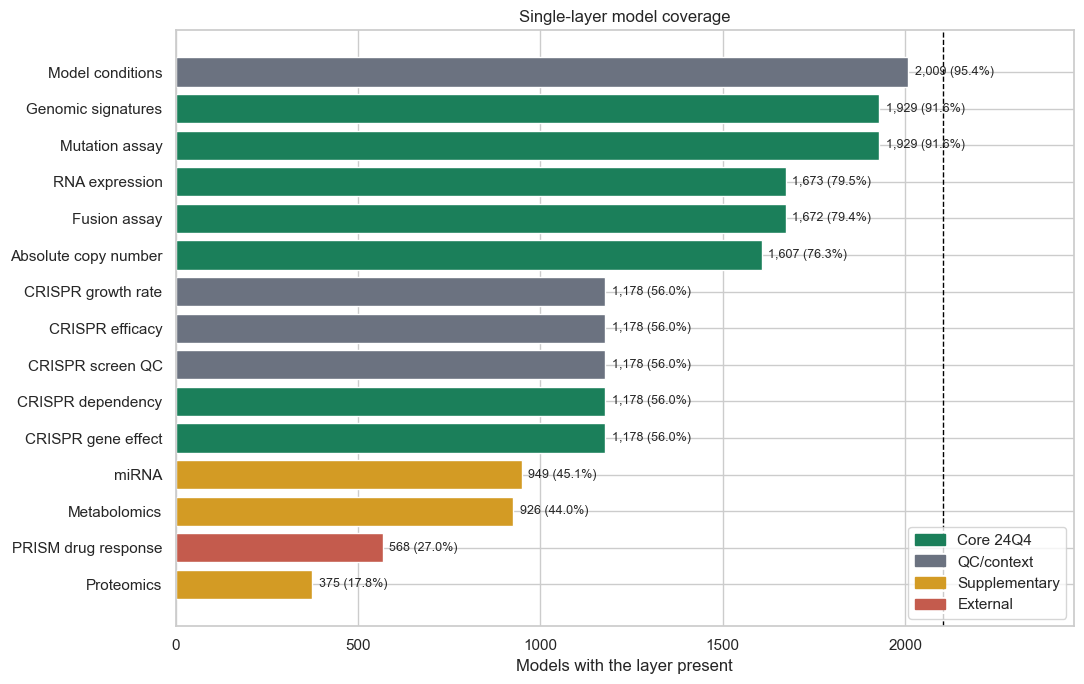

,layer,coverage_group,release_scope,models,coverage_pct
0,Model conditions,QC/context,Release matched,2009,95.439430
1,Mutation assay,Core 24Q4,Release matched,1929,91.638955
2,Genomic signatures,Core 24Q4,Release matched,1929,91.638955
3,RNA expression,Core 24Q4,Release matched,1673,79.477435
4,Fusion assay,Core 24Q4,Release matched,1672,79.429929
5,Absolute copy number,Core 24Q4,Release matched,1607,76.342043
6,CRISPR gene effect,Core 24Q4,Release matched,1178,55.961995
7,CRISPR dependency,Core 24Q4,Release matched,1178,55.961995
8,CRISPR screen QC,QC/context,Release matched,1178,55.961995
9,CRISPR efficacy,QC/context,Release matched,1178,55.961995


In [4]:
layer_specs = [
    ('RNA expression', 'has_expression', 'Core 24Q4', 'Release matched'),
    ('Mutation assay', 'has_mutation_assay', 'Core 24Q4', 'Release matched'),
    ('Fusion assay', 'has_fusion_assay', 'Core 24Q4', 'Release matched'),
    ('Genomic signatures', 'has_genomic_signatures', 'Core 24Q4', 'Release matched'),
    ('CRISPR gene effect', 'has_crispr_gene_effect', 'Core 24Q4', 'Release matched'),
    ('CRISPR dependency', 'has_crispr_dependency', 'Core 24Q4', 'Release matched'),
    ('Absolute copy number', 'has_absolute_copy_number', 'Core 24Q4', 'Release matched'),
    ('Model conditions', 'has_model_condition', 'QC/context', 'Release matched'),
    ('CRISPR screen QC', 'has_crispr_screen_qc', 'QC/context', 'Release matched'),
    ('CRISPR efficacy', 'has_crispr_efficacy', 'QC/context', 'Release matched'),
    ('CRISPR growth rate', 'has_crispr_growth_rate', 'QC/context', 'Release matched'),
    ('Proteomics', 'has_supplementary_proteomics', 'Supplementary', 'Release unmatched'),
    ('miRNA', 'has_supplementary_mirna', 'Supplementary', 'Release unmatched'),
    ('Metabolomics', 'has_supplementary_metabolomics', 'Supplementary', 'Release unmatched'),
]

coverage = master[['model_id', 'oncotree_lineage']].copy()
for layer, flag, _, _ in layer_specs:
    coverage[layer] = master[flag].fillna(0).eq(1)
coverage['PRISM drug response'] = coverage['model_id'].isin(set(prism_ids_raw) & master_ids)

coverage_rows = []
for layer, _, group, release_scope in layer_specs:
    n = int(coverage[layer].sum())
    coverage_rows.append({'layer': layer, 'coverage_group': group, 'release_scope': release_scope, 'models': n, 'coverage_pct': 100 * n / len(coverage)})
prism_n = int(coverage['PRISM drug response'].sum())
coverage_rows.append({'layer': 'PRISM drug response', 'coverage_group': 'External', 'release_scope': 'Release unmatched', 'models': prism_n, 'coverage_pct': 100 * prism_n / len(coverage)})
layer_coverage = pd.DataFrame(coverage_rows).sort_values('models', ascending=True)

manifest_map = {
    'expression_default_rna': ('RNA expression', 'has_expression'),
    'mutations_default_dna': ('Mutation assay', 'has_mutation_assay'),
    'fusions_filtered_model': ('Filtered fusion calls', 'has_any_filtered_fusion_call'),
    'signatures_model': ('Genomic signatures', 'has_genomic_signatures'),
    'crispr_gene_effect': ('CRISPR gene effect', 'has_crispr_gene_effect'),
    'crispr_gene_dependency': ('CRISPR dependency', 'has_crispr_dependency'),
    'absolute_copy_number': ('Absolute copy number', 'has_absolute_copy_number'),
}
manifest_check = expanded_coverage.loc[expanded_coverage['layer'].isin(manifest_map)].copy()
manifest_check[['layer_label', 'flag']] = manifest_check['layer'].map(manifest_map).apply(pd.Series)
manifest_check['master_flag_models'] = manifest_check['flag'].map(lambda c: int(master[c].fillna(0).eq(1).sum()))
manifest_check['difference'] = manifest_check['master_flag_models'] - manifest_check['models_covered']
display(manifest_check[['layer', 'status', 'models_covered', 'master_flag_models', 'difference']])
assert manifest_check['difference'].eq(0).all()
fusion_distinction = pd.DataFrame([
    {'coverage_concept': 'Fusion assay available', 'models': int(master['has_fusion_assay'].fillna(0).eq(1).sum())},
    {'coverage_concept': 'At least one filtered fusion call', 'models': int(master['has_any_filtered_fusion_call'].fillna(0).eq(1).sum())},
    {'coverage_concept': 'Assayed with no retained filtered call', 'models': int((master['has_fusion_assay'].fillna(0).eq(1) & master['has_any_filtered_fusion_call'].fillna(0).eq(0)).sum())},
])
display(fusion_distinction)

palette = {'Core 24Q4': '#1b7f5a', 'QC/context': '#6b7280', 'Supplementary': '#d39b24', 'External': '#c45b4d'}
fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(layer_coverage['layer'], layer_coverage['models'], color=layer_coverage['coverage_group'].map(palette))
for bar, (_, row) in zip(bars, layer_coverage.iterrows()):
    ax.text(bar.get_width() + 18, bar.get_y() + bar.get_height() / 2, f"{row['models']:,} ({row['coverage_pct']:.1f}%)", va='center', fontsize=9)
ax.axvline(len(master), color='black', linestyle='--', linewidth=1, label=f'Identity spine ({len(master):,})')
ax.set_xlim(0, len(master) * 1.17)
ax.set_xlabel('Models with the layer present')
ax.set_ylabel('')
ax.set_title('Single-layer model coverage')
handles = [plt.Rectangle((0, 0), 1, 1, color=color, label=group) for group, color in palette.items()]
ax.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.show()

display(layer_coverage.sort_values('models', ascending=False).reset_index(drop=True))

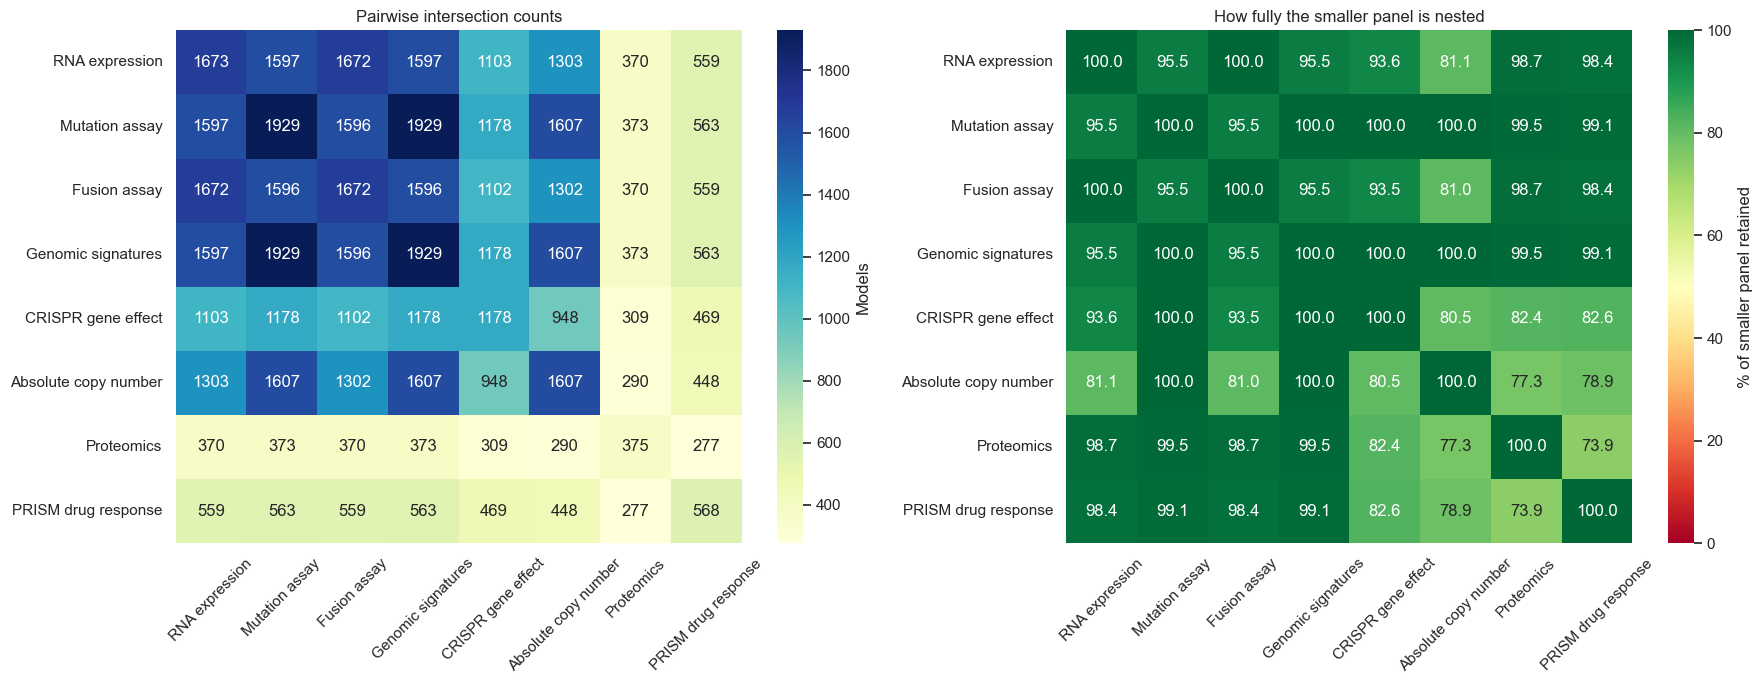

,layer_a,layer_b,intersection_models,smaller_panel_retention_pct
8,Mutation assay,Genomic signatures,1929,100.000000
1,RNA expression,Fusion assay,1672,100.000000
10,Mutation assay,Absolute copy number,1607,100.000000
19,Genomic signatures,Absolute copy number,1607,100.000000
0,RNA expression,Mutation assay,1597,95.457262
2,RNA expression,Genomic signatures,1597,95.457262
7,Mutation assay,Fusion assay,1596,95.454545
13,Fusion assay,Genomic signatures,1596,95.454545
4,RNA expression,Absolute copy number,1303,81.082763
15,Fusion assay,Absolute copy number,1302,81.020535


In [5]:
pair_layers = [
    'RNA expression', 'Mutation assay', 'Fusion assay', 'Genomic signatures',
    'CRISPR gene effect', 'Absolute copy number', 'Proteomics', 'PRISM drug response'
]
layer_counts = coverage[pair_layers].sum()
overlap_counts = pd.DataFrame(index=pair_layers, columns=pair_layers, dtype=int)
smaller_retention = pd.DataFrame(index=pair_layers, columns=pair_layers, dtype=float)

for left in pair_layers:
    for right in pair_layers:
        intersection = int((coverage[left] & coverage[right]).sum())
        overlap_counts.loc[left, right] = intersection
        smaller_retention.loc[left, right] = 100 * intersection / min(layer_counts[left], layer_counts[right])

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(overlap_counts.astype(int), annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Models'}, ax=axes[0])
axes[0].set_title('Pairwise intersection counts')
sns.heatmap(smaller_retention, annot=True, fmt='.1f', cmap='RdYlGn', vmin=0, vmax=100, cbar_kws={'label': '% of smaller panel retained'}, ax=axes[1])
axes[1].set_title('How fully the smaller panel is nested')
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

pair_rows = []
for i, left in enumerate(pair_layers):
    for right in pair_layers[i + 1:]:
        pair_rows.append({
            'layer_a': left,
            'layer_b': right,
            'intersection_models': int(overlap_counts.loc[left, right]),
            'smaller_panel_retention_pct': float(smaller_retention.loc[left, right]),
        })
pairwise_summary = pd.DataFrame(pair_rows).sort_values(['intersection_models', 'smaller_panel_retention_pct'], ascending=[False, False])
display(pairwise_summary)

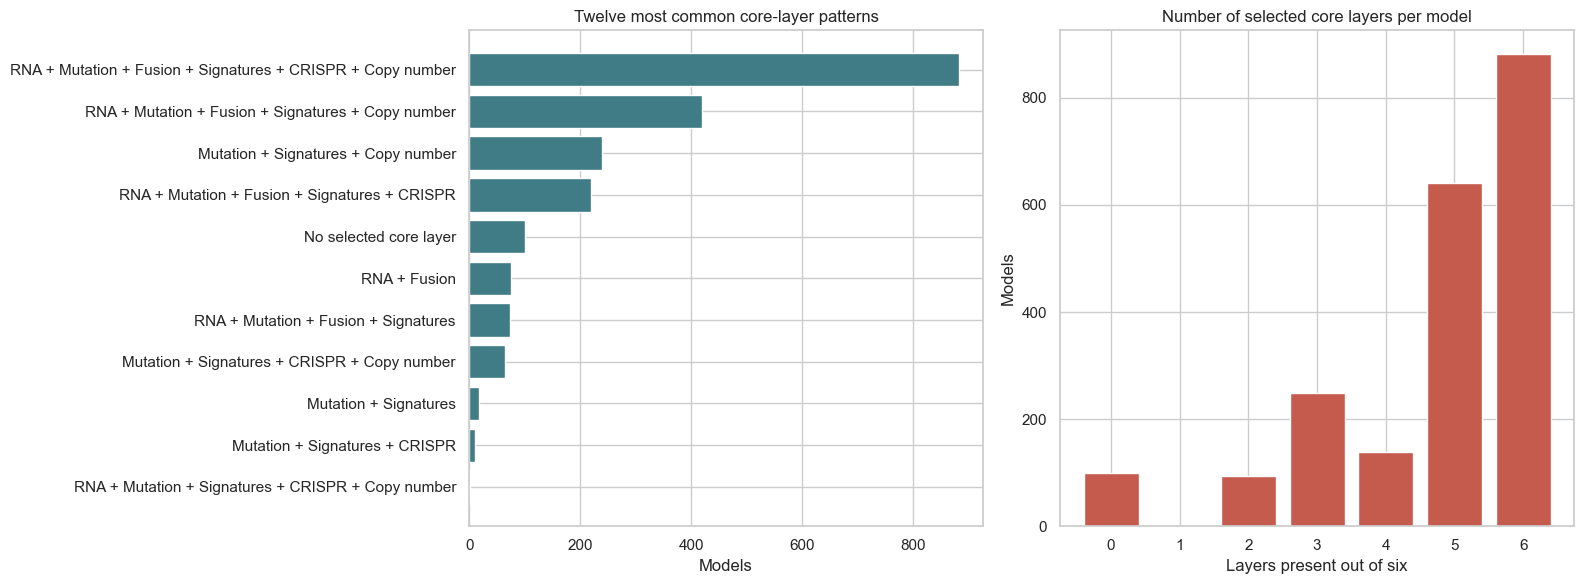

,pattern,models,coverage_pct
8,RNA + Mutation + Fusion + Signatures + CRISPR ...,882,41.900238
9,RNA + Mutation + Fusion + Signatures + Copy nu...,420,19.952494
3,Mutation + Signatures + Copy number,239,11.353919
7,RNA + Mutation + Fusion + Signatures + CRISPR,220,10.451306
4,No selected core layer,100,4.750594
5,RNA + Fusion,76,3.610451
6,RNA + Mutation + Fusion + Signatures,74,3.515439
2,Mutation + Signatures + CRISPR + Copy number,65,3.087886
0,Mutation + Signatures,18,0.855107
1,Mutation + Signatures + CRISPR,10,0.475059


In [6]:
pattern_layers = ['RNA expression', 'Mutation assay', 'Fusion assay', 'Genomic signatures', 'CRISPR gene effect', 'Absolute copy number']
short_names = {
    'RNA expression': 'RNA',
    'Mutation assay': 'Mutation',
    'Fusion assay': 'Fusion',
    'Genomic signatures': 'Signatures',
    'CRISPR gene effect': 'CRISPR',
    'Absolute copy number': 'Copy number',
}


def describe_pattern(row: pd.Series) -> str:
    present = [short_names[layer] for layer in pattern_layers if row[layer]]
    return ' + '.join(present) if present else 'No selected core layer'


coverage['n_selected_core_layers'] = coverage[pattern_layers].sum(axis=1)
coverage['pattern'] = coverage[pattern_layers].apply(describe_pattern, axis=1)
pattern_summary = coverage.groupby('pattern').size().rename('models').reset_index()
pattern_summary['coverage_pct'] = 100 * pattern_summary['models'] / len(coverage)
pattern_summary = pattern_summary.sort_values('models', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_patterns = pattern_summary.head(12).sort_values('models')
axes[0].barh(top_patterns['pattern'], top_patterns['models'], color='#3f7c85')
axes[0].set_title('Twelve most common core-layer patterns')
axes[0].set_xlabel('Models')
core_count_distribution = coverage['n_selected_core_layers'].value_counts().sort_index()
axes[1].bar(core_count_distribution.index, core_count_distribution.values, color='#c45b4d')
axes[1].set_title('Number of selected core layers per model')
axes[1].set_xlabel('Layers present out of six')
axes[1].set_ylabel('Models')
plt.tight_layout()
plt.show()

display(pattern_summary.head(20))

,route,required_layers,n_required_layers,coverage_ready_models,coverage_pct_of_spine,limiting_layer_models,limiting_panel_retention_pct,release_scope
0,Direct fusion evidence,Fusion assay,1,1672,79.429929,1672,100.000000,24Q4 release matched
1,Fusion with RNA validation,Fusion assay + RNA expression,2,1672,79.429929,1672,100.000000,24Q4 release matched
2,CRISPR codependency,CRISPR gene effect + CRISPR dependency,2,1178,55.961995,1178,100.000000,24Q4 release matched
3,Mutation-conditioned dependency,Mutation assay + CRISPR gene effect,2,1178,55.961995,1178,100.000000,24Q4 release matched
5,Expression-conditioned dependency,RNA expression + CRISPR gene effect,2,1103,52.399050,1178,93.633277,24Q4 release matched
4,Copy-number-conditioned dependency,Absolute copy number + CRISPR gene effect,2,948,45.035629,1178,80.475382,24Q4 release matched
6,Multi-omic conditional dependency,Mutation assay + RNA expression + Absolute cop...,4,883,41.947743,1178,74.957555,24Q4 release matched
8,Dependency-drug validation,CRISPR gene effect + PRISM drug response,2,469,22.280285,568,82.570423,Mixed/external validation
9,Translational multi-layer validation,Mutation assay + RNA expression + CRISPR gene ...,4,467,22.185273,568,82.218310,Mixed/external validation
7,RNA-protein validation,RNA expression + Proteomics,2,370,17.577197,375,98.666667,Mixed/external validation


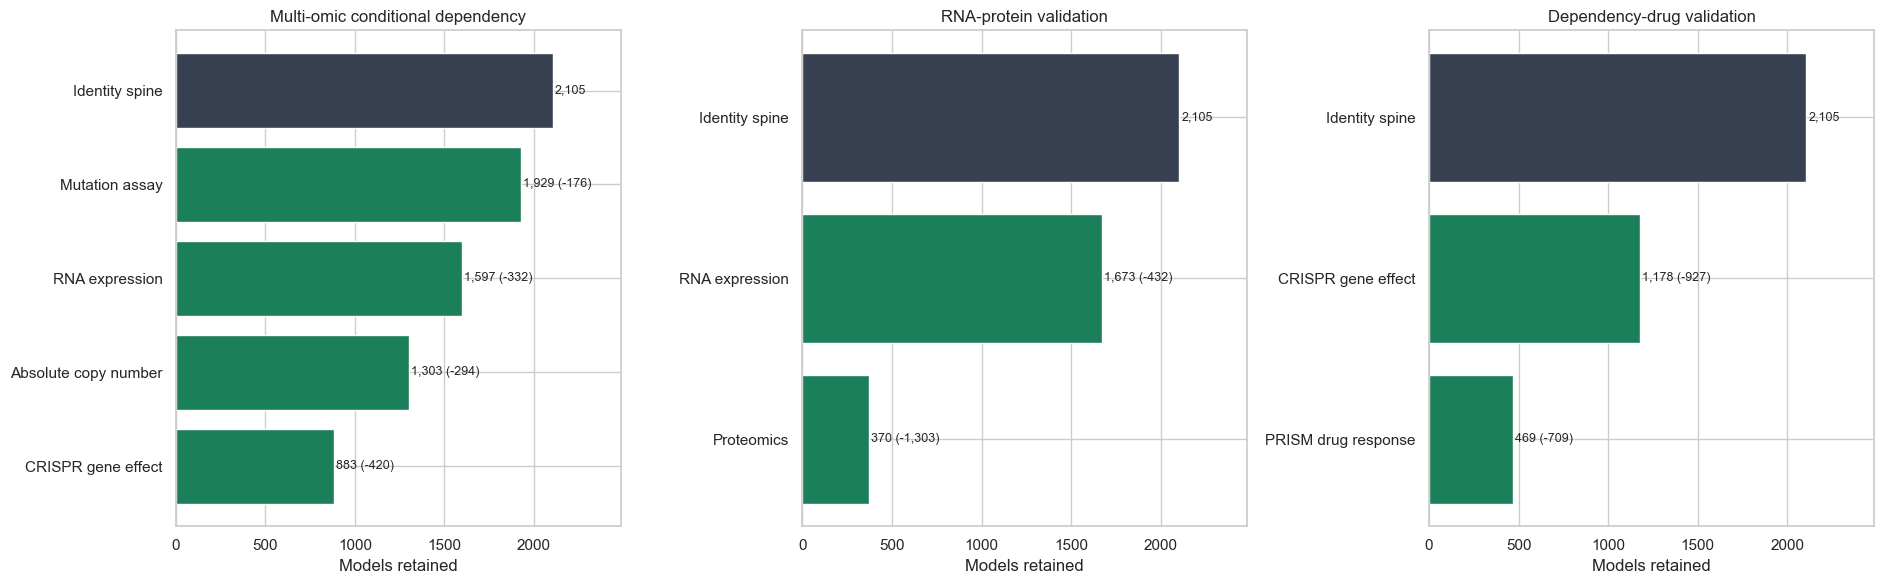

In [7]:
route_definitions = {
    'Direct fusion evidence': ['Fusion assay'],
    'Fusion with RNA validation': ['Fusion assay', 'RNA expression'],
    'CRISPR codependency': ['CRISPR gene effect', 'CRISPR dependency'],
    'Mutation-conditioned dependency': ['Mutation assay', 'CRISPR gene effect'],
    'Copy-number-conditioned dependency': ['Absolute copy number', 'CRISPR gene effect'],
    'Expression-conditioned dependency': ['RNA expression', 'CRISPR gene effect'],
    'Multi-omic conditional dependency': ['Mutation assay', 'RNA expression', 'Absolute copy number', 'CRISPR gene effect'],
    'RNA-protein validation': ['RNA expression', 'Proteomics'],
    'Dependency-drug validation': ['CRISPR gene effect', 'PRISM drug response'],
    'Translational multi-layer validation': ['Mutation assay', 'RNA expression', 'CRISPR gene effect', 'PRISM drug response'],
}

route_rows = []
route_masks = {}
for route, required_layers in route_definitions.items():
    mask = coverage[required_layers].all(axis=1)
    route_masks[route] = mask
    limiting_count = int(coverage[required_layers].sum().min())
    cohort_count = int(mask.sum())
    route_rows.append({
        'route': route,
        'required_layers': ' + '.join(required_layers),
        'n_required_layers': len(required_layers),
        'coverage_ready_models': cohort_count,
        'coverage_pct_of_spine': 100 * cohort_count / len(coverage),
        'limiting_layer_models': limiting_count,
        'limiting_panel_retention_pct': 100 * cohort_count / limiting_count,
        'release_scope': 'Mixed/external validation' if any(layer in required_layers for layer in ['Proteomics', 'PRISM drug response']) else '24Q4 release matched',
    })

route_summary = pd.DataFrame(route_rows).sort_values('coverage_ready_models', ascending=False)
display(route_summary)


def route_waterfall(route: str) -> pd.DataFrame:
    remaining = pd.Series(True, index=coverage.index)
    rows = [{'step': 'Identity spine', 'models': int(remaining.sum()), 'lost_at_step': 0}]
    previous = int(remaining.sum())
    for layer in route_definitions[route]:
        remaining &= coverage[layer]
        current = int(remaining.sum())
        rows.append({'step': layer, 'models': current, 'lost_at_step': previous - current})
        previous = current
    return pd.DataFrame(rows)


waterfall_routes = ['Multi-omic conditional dependency', 'RNA-protein validation', 'Dependency-drug validation']
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
for ax, route in zip(axes, waterfall_routes):
    wf = route_waterfall(route)
    bars = ax.barh(wf['step'], wf['models'], color=['#374151'] + ['#1b7f5a'] * (len(wf) - 1))
    ax.invert_yaxis()
    ax.set_title(route)
    ax.set_xlabel('Models retained')
    for bar, (_, row) in zip(bars, wf.iterrows()):
        label = f"{row['models']:,}" if row['lost_at_step'] == 0 else f"{row['models']:,} (-{row['lost_at_step']:,})"
        ax.text(bar.get_width() + 12, bar.get_y() + bar.get_height() / 2, label, va='center', fontsize=9)
    ax.set_xlim(0, len(coverage) * 1.18)
plt.tight_layout()
plt.show()

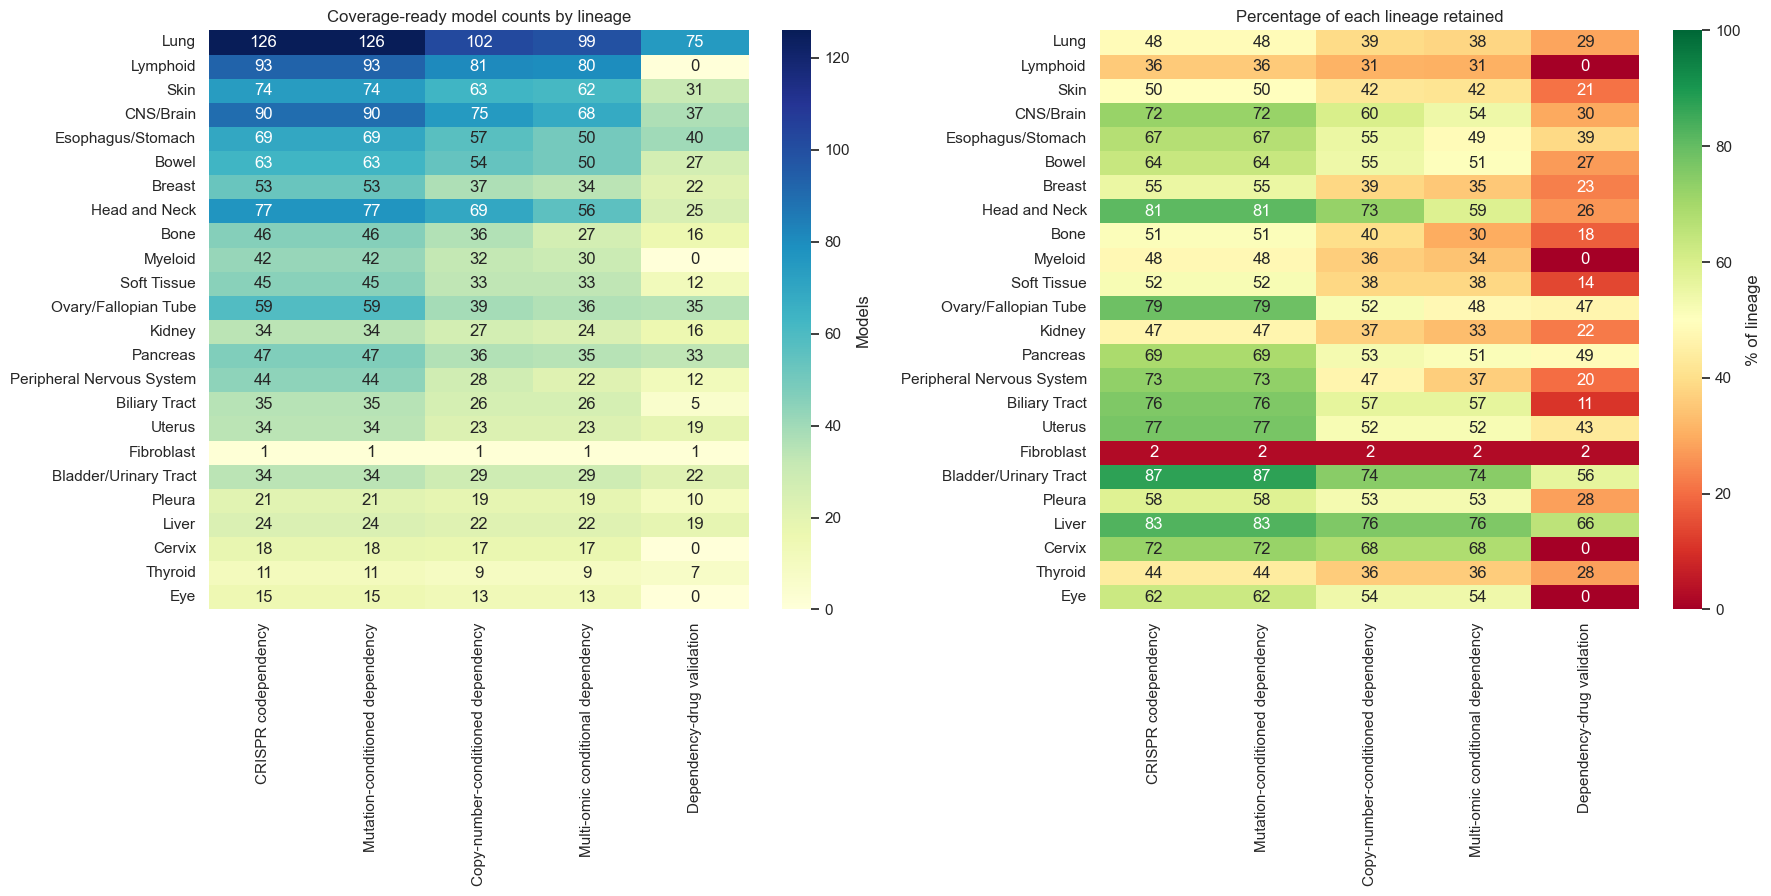

,route,lineages_with_30_or_more_models,lineages_with_15_to_29_models,lineages_with_fewer_than_15_models,largest_lineage_cohort
0,CRISPR codependency,18,4,14,126
1,Mutation-conditioned dependency,18,4,14,126
2,Copy-number-conditioned dependency,13,8,15,102
3,Multi-omic conditional dependency,12,9,15,99
4,Dependency-drug validation,6,8,22,75


,lineage_models,master_share_pct,route_models,route_share_pct,share_shift_pp
lineage,,,,,
Lymphoid,260,12.351544,80,9.060023,-3.291521
Fibroblast,42,1.995249,1,0.113250,-1.881999
Head and Neck,95,4.513064,56,6.342016,1.828952
CNS/Brain,125,5.938242,68,7.701019,1.762777
Bladder/Urinary Tract,39,1.852732,29,3.284258,1.431527
Bone,90,4.275534,27,3.057758,-1.217777
Lung,260,12.351544,99,11.211778,-1.139766
Liver,29,1.377672,22,2.491506,1.113834
Bowel,99,4.703088,50,5.662514,0.959426


In [8]:
coverage['lineage'] = coverage['oncotree_lineage'].fillna('Unknown')
lineage_sizes = coverage.groupby('lineage').size().rename('lineage_models')
lineage_routes = pd.DataFrame(index=lineage_sizes.index)
for route, mask in route_masks.items():
    lineage_routes[route] = coverage.loc[mask].groupby('lineage').size().reindex(lineage_sizes.index, fill_value=0)

focus_routes = [
    'CRISPR codependency',
    'Mutation-conditioned dependency',
    'Copy-number-conditioned dependency',
    'Multi-omic conditional dependency',
    'Dependency-drug validation',
]
lineages_to_plot = lineage_sizes.loc[lineage_sizes.ge(20)].sort_values(ascending=False).index
count_matrix = lineage_routes.loc[lineages_to_plot, focus_routes]
percent_matrix = count_matrix.div(lineage_sizes.loc[lineages_to_plot], axis=0) * 100

height = max(8, 0.38 * len(lineages_to_plot))
fig, axes = plt.subplots(1, 2, figsize=(18, height))
sns.heatmap(count_matrix, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Models'}, ax=axes[0])
axes[0].set_title('Coverage-ready model counts by lineage')
sns.heatmap(percent_matrix, annot=True, fmt='.0f', cmap='RdYlGn', vmin=0, vmax=100, cbar_kws={'label': '% of lineage'}, ax=axes[1])
axes[1].set_title('Percentage of each lineage retained')
for ax in axes:
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

suitability_rows = []
for route in focus_routes:
    counts = lineage_routes[route]
    suitability_rows.append({
        'route': route,
        'lineages_with_30_or_more_models': int(counts.ge(30).sum()),
        'lineages_with_15_to_29_models': int(counts.between(15, 29).sum()),
        'lineages_with_fewer_than_15_models': int(counts.lt(15).sum()),
        'largest_lineage_cohort': int(counts.max()),
    })
suitability = pd.DataFrame(suitability_rows)
display(suitability)

focus_route = 'Multi-omic conditional dependency'
focus_mask = route_masks[focus_route]
master_distribution = lineage_sizes / len(coverage)
route_distribution = coverage.loc[focus_mask].groupby('lineage').size().reindex(lineage_sizes.index, fill_value=0) / int(focus_mask.sum())
lineage_bias = pd.DataFrame({
    'lineage_models': lineage_sizes,
    'master_share_pct': 100 * master_distribution,
    'route_models': lineage_routes[focus_route],
    'route_share_pct': 100 * route_distribution,
})
lineage_bias['share_shift_pp'] = lineage_bias['route_share_pct'] - lineage_bias['master_share_pct']
lineage_bias['absolute_shift_pp'] = lineage_bias['share_shift_pp'].abs()
display(lineage_bias.sort_values('absolute_shift_pp', ascending=False).head(20).drop(columns='absolute_shift_pp'))

In [9]:
cross_layer_cohort_manifest = coverage[['model_id', 'oncotree_lineage', *[item[0] for item in layer_specs], 'PRISM drug response']].copy()
for route, mask in route_masks.items():
    cross_layer_cohort_manifest[f"route__{route.lower().replace(' ', '_').replace('-', '_')}"] = mask.values

decision_table = pd.DataFrame([
    {'decision': 'Model join key', 'rule': 'Use model_id only; names and RRIDs remain review fields.'},
    {'decision': 'Assay absence', 'rule': 'Keep as unknown. Never convert missing coverage to biological zero.'},
    {'decision': 'Event-table joins', 'rule': 'Aggregate to the required model or model-gene grain before joining.'},
    {'decision': 'RNA and DNA profiles', 'rule': 'Use selected default profiles so each model contributes once.'},
    {'decision': 'CRISPR context', 'rule': 'Carry screen/library QC, growth, and efficacy as confidence context.'},
    {'decision': 'Lineage analysis', 'rule': 'Report exact denominators; do not pool tiny lineages for interpretation.'},
    {'decision': 'Supplementary/PRISM data', 'rule': 'Use for sensitivity or validation with release status visible.'},
    {'decision': 'TCGA and networks', 'rule': 'Keep on patient and gene axes; connect later through disease or stable gene identifiers.'},
    {'decision': 'Route flags', 'rule': 'Treat as cohort definitions only, never as evidence that a pair is biologically valid.'},
])

display(decision_table)
print(f'Cohort manifest shape: {cross_layer_cohort_manifest.shape}')
display(cross_layer_cohort_manifest.head())

assert cross_layer_cohort_manifest['model_id'].is_unique
assert not cross_layer_cohort_manifest.drop(columns=['model_id', 'oncotree_lineage']).isna().any().any()
for route, required_layers in route_definitions.items():
    route_count = int(route_masks[route].sum())
    assert route_count <= int(coverage[required_layers].sum().min())

,decision,rule
0,Model join key,Use model_id only; names and RRIDs remain revi...
1,Assay absence,Keep as unknown. Never convert missing coverag...
2,Event-table joins,Aggregate to the required model or model-gene ...
3,RNA and DNA profiles,Use selected default profiles so each model co...
4,CRISPR context,"Carry screen/library QC, growth, and efficacy ..."
5,Lineage analysis,Report exact denominators; do not pool tiny li...
6,Supplementary/PRISM data,Use for sensitivity or validation with release...
7,TCGA and networks,Keep on patient and gene axes; connect later t...
8,Route flags,"Treat as cohort definitions only, never as evi..."


Cohort manifest shape: (2105, 27)


,model_id,oncotree_lineage,RNA expression,Mutation assay,Fusion assay,Genomic signatures,CRISPR gene effect,CRISPR dependency,Absolute copy number,Model conditions,CRISPR screen QC,CRISPR efficacy,CRISPR growth rate,Proteomics,miRNA,Metabolomics,PRISM drug response,route__direct_fusion_evidence,route__fusion_with_rna_validation,route__crispr_codependency,route__mutation_conditioned_dependency,route__copy_number_conditioned_dependency,route__expression_conditioned_dependency,route__multi_omic_conditional_dependency,route__rna_protein_validation,route__dependency_drug_validation,route__translational_multi_layer_validation
0,ACH-000001,Ovary/Fallopian Tube,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True,True
1,ACH-000002,Myeloid,True,True,True,True,False,False,True,True,False,False,False,False,True,True,False,True,True,False,False,False,False,False,False,False,False
2,ACH-000003,Bowel,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False
3,ACH-000004,Myeloid,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True,False,False
4,ACH-000005,Myeloid,True,True,True,True,True,True,True,True,True,True,True,True,True,True,False,True,True,True,True,True,True,True,True,False,False
